# **Early Detection and Classification of Breast Cancer Using Deep Learning Techniques on Medical Imaging Data**

Dataset Link - https://www.kaggle.com/datasets/vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer

In [1]:
from google.colab import files
uploaded = files.upload()

import os
if 'kaggle.json' in uploaded:
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    os.rename('kaggle.json', os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print("kaggle.json uploaded and configured")
else:
    print("Please upload kaggle.json file")

!pip install -q kaggle

!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer -q

os.makedirs("./ultrasound_dataset", exist_ok=True)
!unzip -o -q ultrasound-breast-images-for-breast-cancer.zip -d ./ultrasound_dataset

!rm ultrasound-breast-images-for-breast-cancer.zip

print("Dataset downloaded and unzipped to ./ultrasound_dataset")

Saving kaggle.json to kaggle.json
kaggle.json uploaded and configured
Dataset URL: https://www.kaggle.com/datasets/vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
License(s): CC0-1.0
Dataset downloaded and unzipped to ./ultrasound_dataset


Folder: /content/ultrasound_dataset/ultrasound breast classification
Folder: /content/ultrasound_dataset/ultrasound breast classification/train
Folder: /content/ultrasound_dataset/ultrasound breast classification/train/benign
  - benign (187)-sharpened.png
  - benign (163)-rotated2-rotated2.png
  - benign (151)-sharpened-rotated2.png
  - benign (262)-rotated2.jpg
  - benign (81)-rotated2-rotated1.png
Folder: /content/ultrasound_dataset/ultrasound breast classification/train/malignant
  - malignant (185)-rotated32-rotated1.png
  - malignant (130)-rotated2.png
  - malignant (113)-rotated32-sharpened.png
  - malignant (60)-rotated32.png
  - malignant (152)-sharpened-rotated1.png
Folder: /content/ultrasound_dataset/ultrasound breast classification/val
Folder: /content/ultrasound_dataset/ultrasound breast classification/val/benign
  - benign (1)-rotated2.jpg
  - benign (1)-rotated1.png
  - benign (17)-sharpened.jpg
  - benign (12)-rotated1-rotated2.png
  - benign (20)-sharpened-sharpened.pn

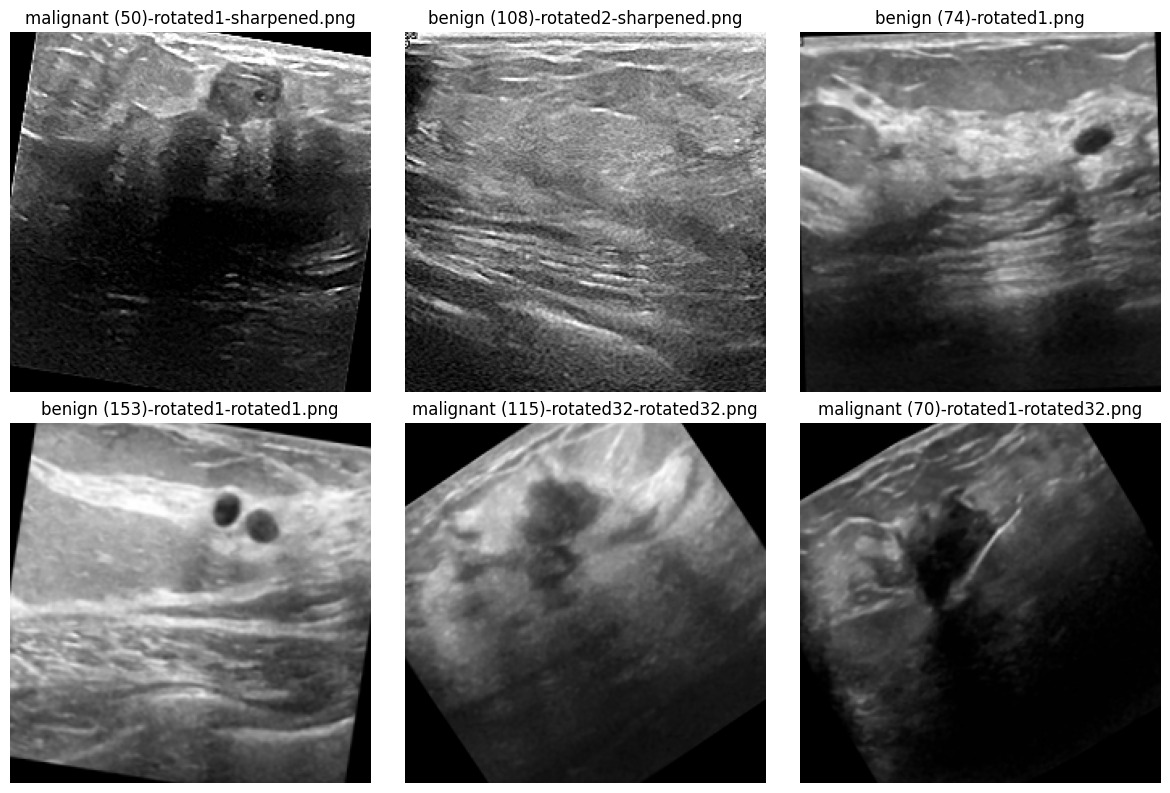

In [2]:
import os
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
import random


dataset_path = '/content/ultrasound_dataset/ultrasound breast classification'


for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    for f in files[:5]:
        print(f"  - {f}")

print("\nDisplaying sample images...\n")
all_images = []
for subdir, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".png"):
            all_images.append(os.path.join(subdir, file))


sample_images = random.sample(all_images, 6)

plt.figure(figsize=(12, 8))
for i, img_path in enumerate(sample_images):
    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
import os

dataset_path = '/content/ultrasound_dataset/ultrasound breast classification'

print("Folder structure:\n")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}- {os.path.basename(root)}/")
    sub_indent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{sub_indent}- {f}")
    if len(files) > 5:
        print(f"{sub_indent}- ... ({len(files)-5} more files)")


splits = ['train', 'val']
for split in splits:
    split_path = os.path.join(dataset_path, split)
    print(f"\n {split} image counts:")
    total_split = 0
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path) if f.endswith('.png')]
            print(f"  - {cls}: {len(imgs)} images")
            total_split += len(imgs)
    print(f"  Total images in {split}: {total_split}")

Folder structure:

- ultrasound breast classification/
    - train/
        - benign/
            - benign (187)-sharpened.png
            - benign (163)-rotated2-rotated2.png
            - benign (151)-sharpened-rotated2.png
            - benign (262)-rotated2.jpg
            - benign (81)-rotated2-rotated1.png
            - ... (4069 more files)
        - malignant/
            - malignant (185)-rotated32-rotated1.png
            - malignant (130)-rotated2.png
            - malignant (113)-rotated32-sharpened.png
            - malignant (60)-rotated32.png
            - malignant (152)-sharpened-rotated1.png
            - ... (4037 more files)
    - val/
        - benign/
            - benign (1)-rotated2.jpg
            - benign (1)-rotated1.png
            - benign (17)-sharpened.jpg
            - benign (12)-rotated1-rotated2.png
            - benign (20)-sharpened-sharpened.png
            - ... (495 more files)
        - malignant/
            - malignant (1)-rotated1-rotated2-ro

## Class distribution

In [4]:
splits = ['train', 'val']
print("Class distribution per split:\n")
for split in splits:
    split_path = os.path.join(dataset_path, split)
    counts = {}
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        img_files = [f for f in os.listdir(cls_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        counts[cls] = len(img_files)
    print(f"{split}: {counts}")


Class distribution per split:

train: {'benign': 4074, 'malignant': 4042}
val: {'benign': 500, 'malignant': 400}


## Image size statistics

In [5]:
import cv2
import numpy as np
print("\nImage size statistics:")
all_sizes = []
for split in splits:
    for cls in os.listdir(os.path.join(dataset_path, split)):
        cls_path = os.path.join(dataset_path, split, cls)
        for f in os.listdir(cls_path):
            if f.endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(os.path.join(cls_path, f))
                if img is not None:
                    all_sizes.append(img.shape)
all_sizes = np.array(all_sizes)
print(f"Number of images: {len(all_sizes)}")
print(f"Height: min={all_sizes[:,0].min()}, max={all_sizes[:,0].max()}, mean={all_sizes[:,0].mean():.1f}")
print(f"Width: min={all_sizes[:,1].min()}, max={all_sizes[:,1].max()}, mean={all_sizes[:,1].mean():.1f}")
print(f"Channels: {set(all_sizes[:,2])}")




Image size statistics:
Number of images: 9016
Height: min=224, max=227, mean=224.2
Width: min=224, max=227, mean=224.2
Channels: {np.int64(3)}


## Check for corrupt images

In [6]:
corrupt_count = 0
for split in splits:
    for cls in os.listdir(os.path.join(dataset_path, split)):
        cls_path = os.path.join(dataset_path, split, cls)
        for f in os.listdir(cls_path):
            if f.endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(os.path.join(cls_path, f))
                if img is None:
                    corrupt_count += 1
print(f"Number of corrupt/unreadable images: {corrupt_count}")

Number of corrupt/unreadable images: 0


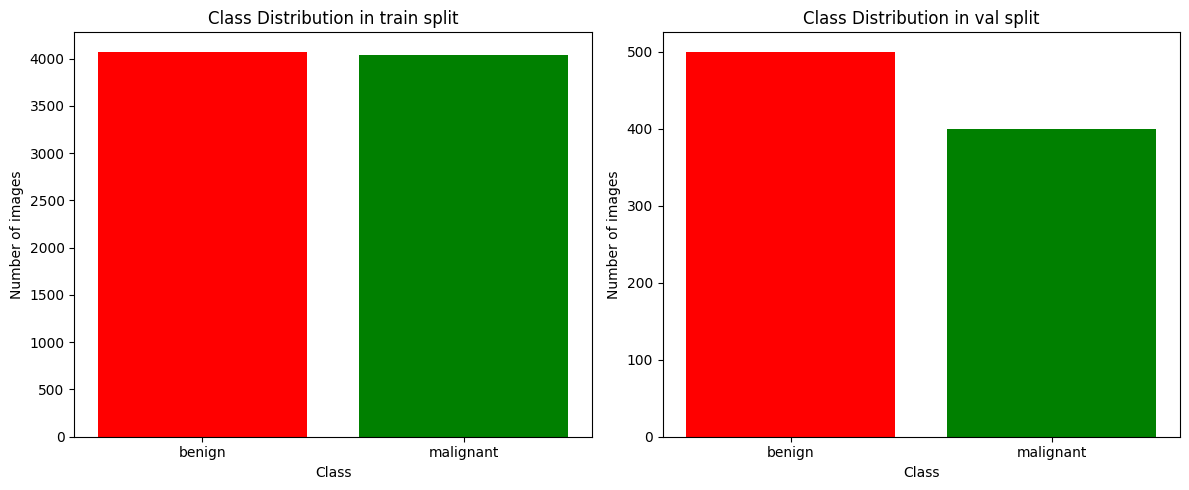

In [7]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np


class_counts = {}
for split in splits:
    split_path = os.path.join(dataset_path, split)
    counts = {}
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        img_files = [f for f in os.listdir(cls_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        counts[cls] = len(img_files)
    class_counts[split] = counts


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, split in enumerate(splits):
    ax[i].bar(class_counts[split].keys(), class_counts[split].values(), color=['red', 'green'])
    ax[i].set_title(f'Class Distribution in {split} split')
    ax[i].set_xlabel('Class')
    ax[i].set_ylabel('Number of images')
plt.tight_layout()
plt.show()



Text(0, 0.5, 'Number of images')

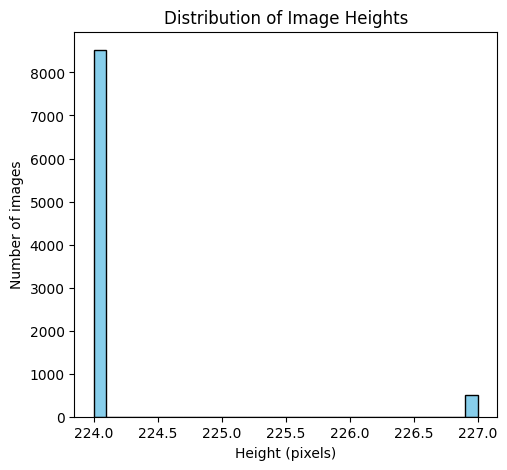

In [8]:
# 3. Image size distribution
heights = []
widths = []

for split in splits:
    for cls in os.listdir(os.path.join(dataset_path, split)):
        cls_path = os.path.join(dataset_path, split, cls)
        for f in os.listdir(cls_path):
            if f.endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(os.path.join(cls_path, f))
                if img is not None:
                    h, w = img.shape[:2]
                    heights.append(h)
                    widths.append(w)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(heights, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Image Heights')
plt.xlabel('Height (pixels)')
plt.ylabel('Number of images')

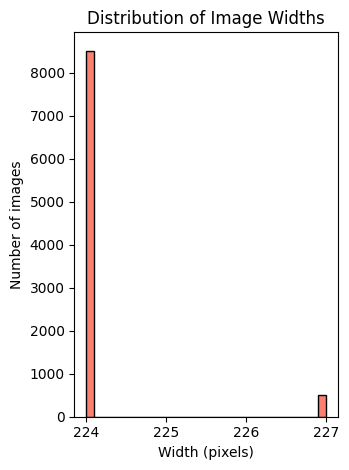

In [9]:
plt.subplot(1, 2, 2)
plt.hist(widths, bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Image Widths')
plt.xlabel('Width (pixels)')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

##Data augmentation

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,                # Normalize pixel values
    rotation_range=20,              # Random rotations
    width_shift_range=0.1,          # Horizontal shifts
    height_shift_range=0.1,         # Vertical shifts
    shear_range=0.1,                # Shear transformations
    zoom_range=0.1,                 # Random zoom
    horizontal_flip=True,           # Flip horizontally
    vertical_flip=False,            # Do not flip vertically
    fill_mode='nearest'             # Fill missing pixels after transformation
)


val_datagen = ImageDataGenerator(rescale=1./255)


train_dir = '/content/ultrasound_dataset/ultrasound breast classification/train'
val_dir = '/content/ultrasound_dataset/ultrasound breast classification/val'


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to fixed size
    batch_size=32,
    class_mode='binary'      # Binary classification: malignant/benign
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)



Found 8116 images belonging to 2 classes.
Found 900 images belonging to 2 classes.


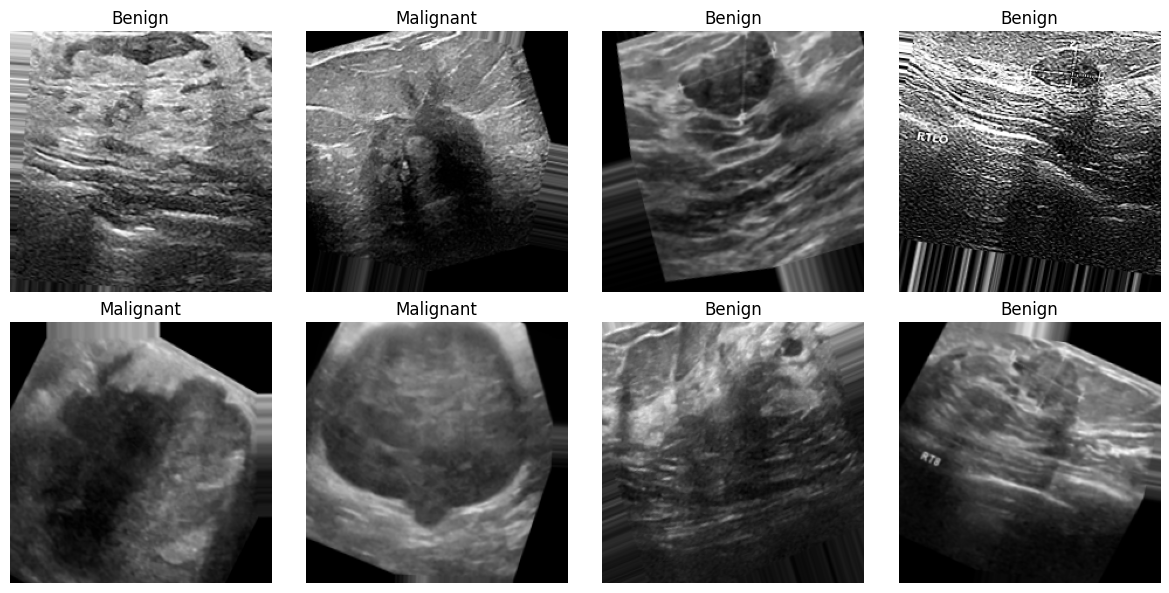

In [11]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_batch[i])
    plt.title("Malignant" if y_batch[i]==1 else "Benign")
    plt.axis('off')
plt.tight_layout()
plt.show()

## **Model Building**

# MobileNetV2 Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load pretrained model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.3,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [ ]:
mobilenet_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 148s 507ms/step - accuracy: 0.5546 - loss: 0.7620 - val_accuracy: 0.7156 - val_loss: 0.5958 - learning_rate: 1.0000e-05
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 102s 403ms/step - accuracy: 0.6345 - loss: 0.6533 - val_accuracy: 0.7700 - val_loss: 0.5375 - learning_rate: 1.0000e-05
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 104s 408ms/step - accuracy: 0.6817 - loss: 0.5946 - val_accuracy: 0.7944 - val_loss: 0.5008 - learning_rate: 1.0000e-05
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 103s 404ms/step - accuracy: 0.7052 - loss: 0.5634 - val_accuracy: 0.7867 - val_loss: 0.4801 - learning_rate: 1.0000e-05
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 104s 410ms/step - accuracy: 0.7368 - loss: 0.5250 - val_accuracy: 0.7978 - val_loss: 0.4575 - learning_rate: 1.0000e-05
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 104s 410ms/step - accuracy: 0.7446 - loss: 0.5122 - val_accuracy: 0.8022 - val_loss: 0.4397 - learning_rate: 1.0000e-05
Epoch 7/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 

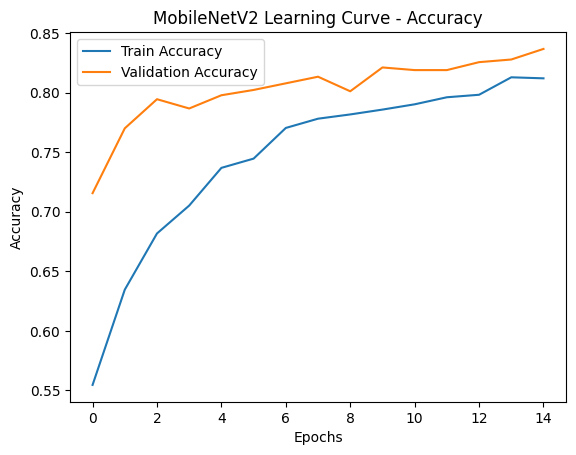

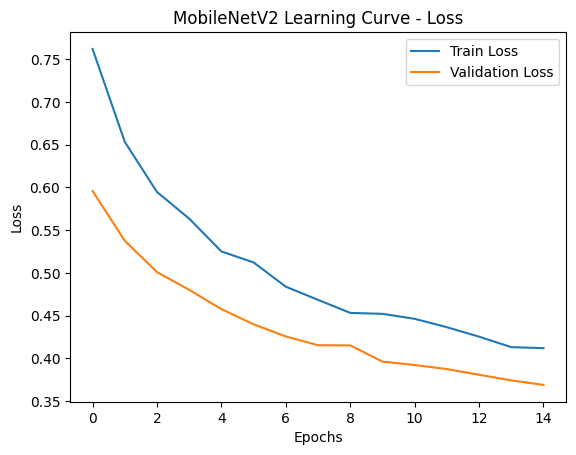

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Learning Curve - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(mobilenet_history.history['loss'], label='Train Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Learning Curve - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np

val_generator.shuffle = False

y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()
y_true = val_generator.classes

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8366666666666667
Precision: 0.8731563421828908
Recall   : 0.74
F1 Score : 0.8010825439783491


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.81      0.91      0.86       500
    Positive       0.87      0.74      0.80       400

    accuracy                           0.84       900
   macro avg       0.84      0.83      0.83       900
weighted avg       0.84      0.84      0.83       900



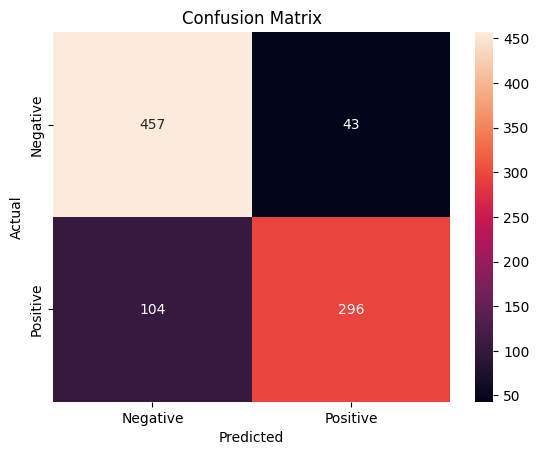

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

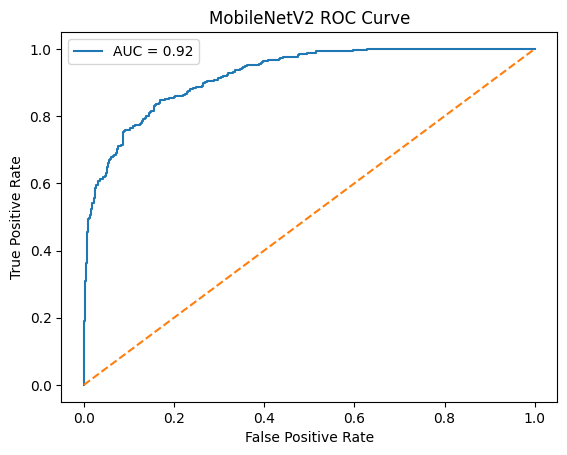

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MobileNetV2 ROC Curve')
plt.legend()
plt.show()

# DenseNet121 Model

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

train_dir = '/content/ultrasound_dataset/ultrasound breast classification/train'
val_dir   = '/content/ultrasound_dataset/ultrasound breast classification/val'


# Data generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


# Load DenseNet121 base model
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False


# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model for initial training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)


# Fine-tuning training
denseNet_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Found 8116 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 188s 606ms/step - accuracy: 0.5193 - loss: 0.7859 - val_accuracy: 0.5511 - val_loss: 0.6954 - learning_rate: 1.0000e-05
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 114s 449ms/step - accuracy: 0.5626 - loss: 0.7168 - val_accuracy: 0.6800 - val_loss: 0.6201 - learning_rate: 1.0000e-05
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 113s 444ms/step - accuracy: 0.6185 - loss: 0.6558 - val_accuracy: 0.7156 - val_loss: 0.5774 - learning_rate: 1.0000e-05
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 113s 443ms/step - accuracy: 0.6435 - loss: 0.6273 - val_accuracy: 0.7456 - val_loss: 0.5425 - learning_rate: 1.0000e-05
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 114s 447ms/step - accuracy: 0.6671 - loss: 0.6004 - val_accuracy: 0.7667 - val_loss: 0.5214 - learning_rate: 1.0000e-05
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 113s 444ms/step - accuracy

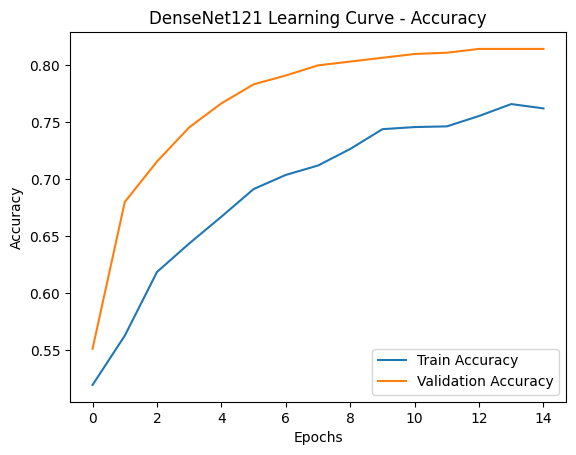

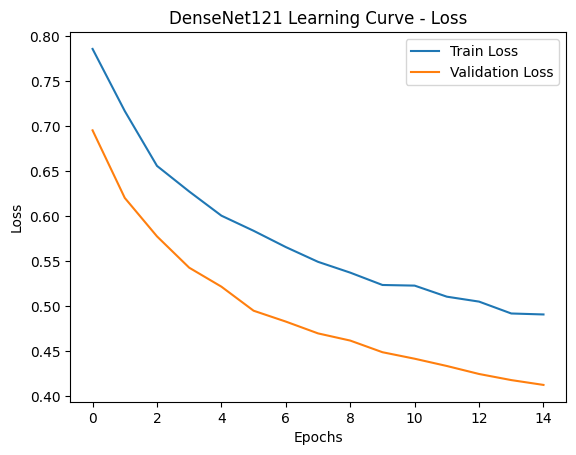

In [15]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(denseNet_history.history['accuracy'], label='Train Accuracy')
plt.plot(denseNet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet121 Learning Curve - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(denseNet_history.history['loss'], label='Train Loss')
plt.plot(denseNet_history.history['val_loss'], label='Validation Loss')
plt.title('DenseNet121 Learning Curve - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

#  Predictions
val_generator.reset()

y_true = val_generator.classes
y_pred_prob = model.predict(val_generator, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()


# Metrics

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


#  Classification Report

print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

Found 900 images belonging to 2 classes.
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step

 Metrics:
Accuracy:  0.8144
Precision: 0.8026
Recall:    0.7725
F1-score:  0.7873

 Classification Report:
              precision    recall  f1-score   support

      benign       0.82      0.85      0.84       500
   malignant       0.80      0.77      0.79       400

    accuracy                           0.81       900
   macro avg       0.81      0.81      0.81       900
weighted avg       0.81      0.81      0.81       900



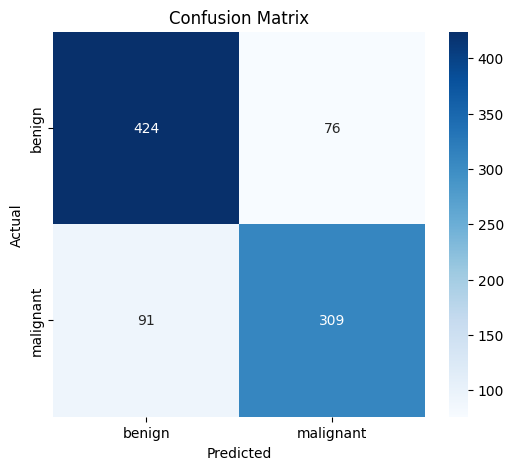

In [31]:
#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



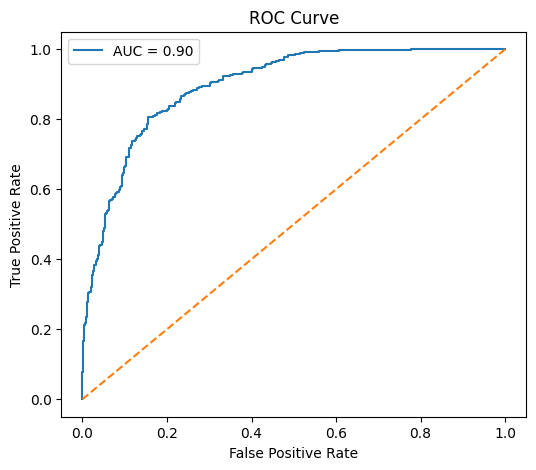

ROC AUC Score: 0.8971


In [32]:
#  ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

# InceptionV3 Model

In [33]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

train_dir = '/content/ultrasound_dataset/ultrasound breast classification/train'
val_dir   = '/content/ultrasound_dataset/ultrasound breast classification/val'


# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load InceptionV3
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False


# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'inception_best.keras',
    monitor='val_accuracy',
    save_best_only=True
)


# Training
inception_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Found 8116 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 175s 594ms/step - accuracy: 0.5683 - loss: 0.7351 - val_accuracy: 0.7011 - val_loss: 0.5755 - learning_rate: 1.0000e-05
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 113s 444ms/step - accuracy: 0.6891 - loss: 0.5805 - val_accuracy: 0.7289 - val_loss: 0.5083 - learning_rate: 1.0000e-05
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 114s 451ms/step - accuracy: 0.7294 - loss: 0.5320 - val_accuracy: 0.7133 - val_loss: 0.4996 - learning_rate: 1.0000e-05
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 112s 441ms/step - accuracy: 0.7532 - loss: 0.4989 - val_accuracy: 0.7322 - val_loss: 0.4816 - learning_rate: 1.0000e-05
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 111s 436ms/step - accuracy: 0.7570 - loss: 0.4834 - val_accuracy: 0.7578 - val_loss: 0.4564 - learning_rate: 1.0000e-05
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 110s 434ms/step - accuracy

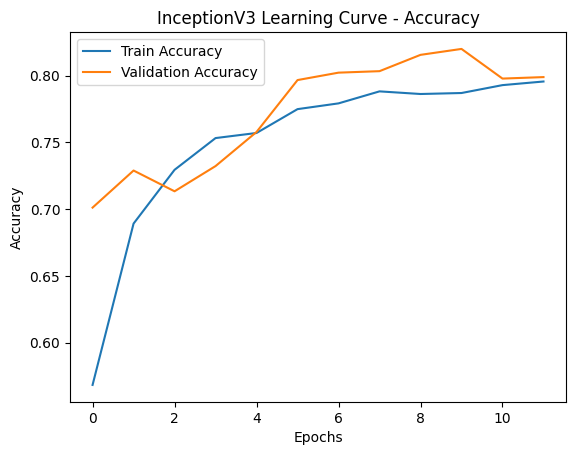

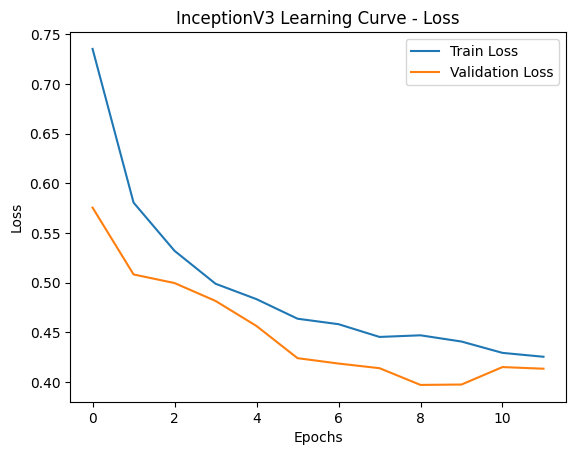

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)

#  Learning Curves
plt.figure()

plt.plot(inception_history.history['accuracy'], label='Train Accuracy')
plt.plot(inception_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 Learning Curve - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()

plt.plot(inception_history.history['loss'], label='Train Loss')
plt.plot(inception_history.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 Learning Curve - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:

#  Predictions
# -----------------------------
val_generator.reset()

y_true = val_generator.classes
y_pred_prob = model.predict(val_generator, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()


#  Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

#  Classification Report
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))



29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step

 Metrics:
Accuracy:  0.8156
Precision: 0.9718
Recall:    0.6025
F1-score:  0.7438

 Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.99      0.86       500
   malignant       0.97      0.60      0.74       400

    accuracy                           0.82       900
   macro avg       0.86      0.79      0.80       900
weighted avg       0.85      0.82      0.81       900



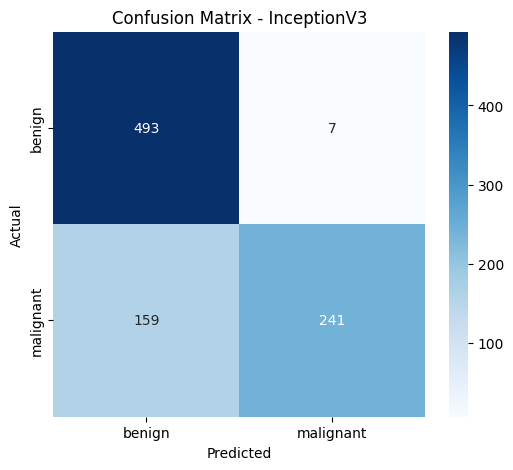

In [37]:
#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.title("Confusion Matrix - InceptionV3")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



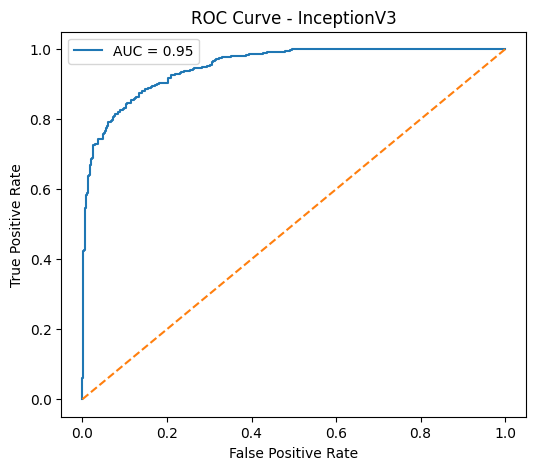

ROC AUC Score: 0.9507


In [38]:
#  ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - InceptionV3")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

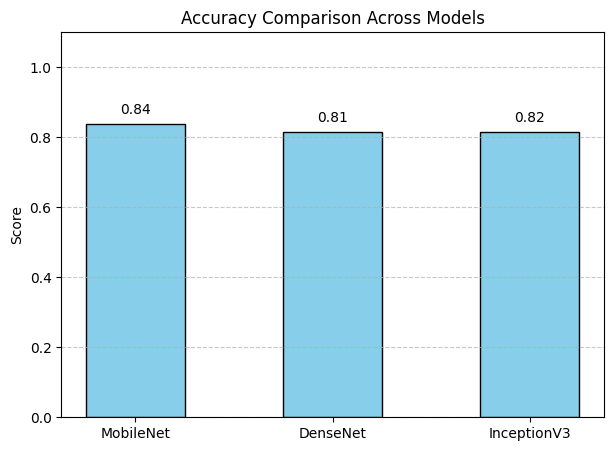

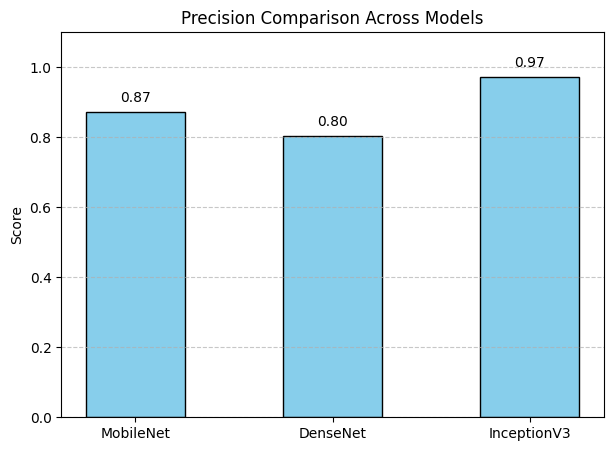

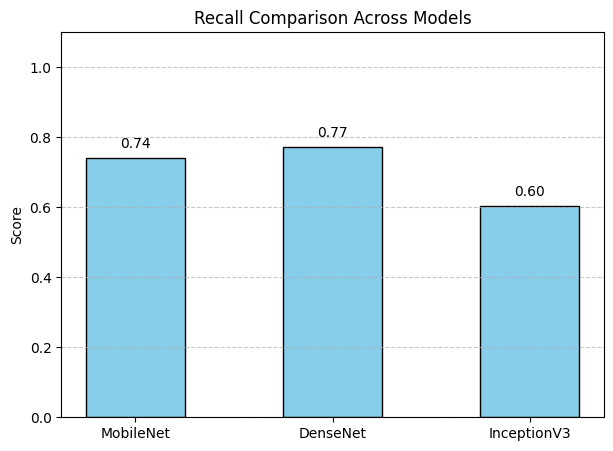

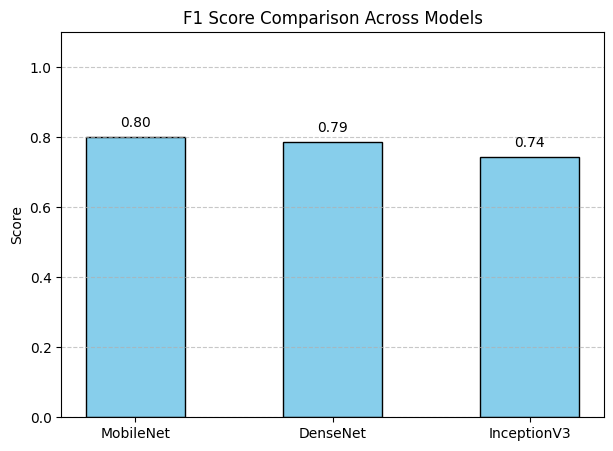

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['MobileNet', 'DenseNet', 'InceptionV3']

# Metrics
accuracy = [0.8367, 0.8144, 0.8156]
precision = [0.8732, 0.8026, 0.9718]
recall = [0.74, 0.7725, 0.6025]
f1_score = [0.8011, 0.7873, 0.7438]

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1_score
}

x = np.arange(len(models))
bar_width = 0.5

# Function to create individual plots
def plot_metric(metric_name, values):
    plt.figure(figsize=(7,5))
    bars = plt.bar(x, values, width=bar_width, color='skyblue', edgecolor='black')

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10)

    plt.xticks(x, models)
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.title(f'{metric_name} Comparison Across Models')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Plot each metric individually
for metric_name, values in metrics.items():
    plot_metric(metric_name, values)

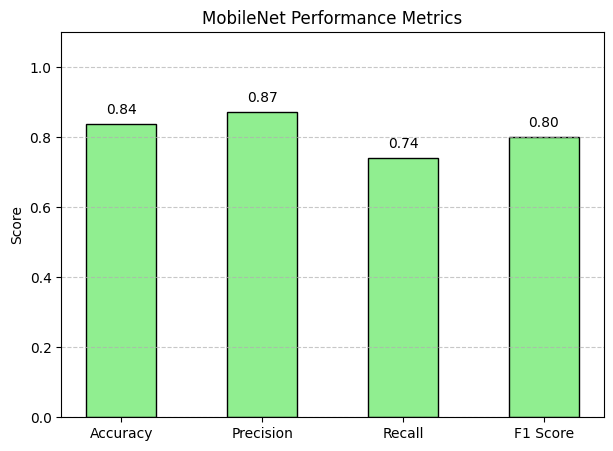

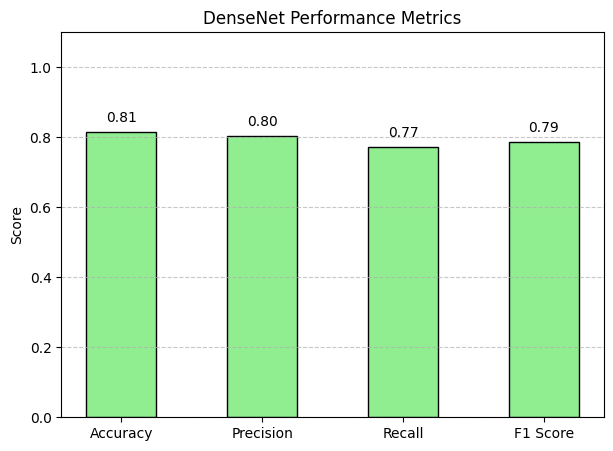

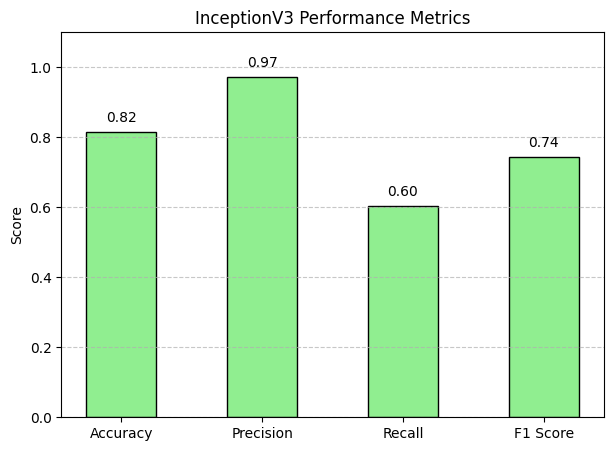

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Models and their metrics
models_metrics = {
    'MobileNet': {'Accuracy': 0.8367, 'Precision': 0.8732, 'Recall': 0.74, 'F1 Score': 0.8011},
    'DenseNet': {'Accuracy': 0.8144, 'Precision': 0.8026, 'Recall': 0.7725, 'F1 Score': 0.7873},
    'InceptionV3': {'Accuracy': 0.8156, 'Precision': 0.9718, 'Recall': 0.6025, 'F1 Score': 0.7438}
}

# Function to plot metrics for a single model
def plot_model_metrics(model_name, metrics_dict):
    metrics_names = list(metrics_dict.keys())
    values = list(metrics_dict.values())

    x = np.arange(len(metrics_names))
    bar_width = 0.5

    plt.figure(figsize=(7,5))
    bars = plt.bar(x, values, width=bar_width, color='lightgreen', edgecolor='black')

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10)

    plt.xticks(x, metrics_names)
    plt.ylim(0, 1.1)
    plt.ylabel('Score')
    plt.title(f'{model_name} Performance Metrics')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Plot each model individually
for model_name, metrics_dict in models_metrics.items():
    plot_model_metrics(model_name, metrics_dict)

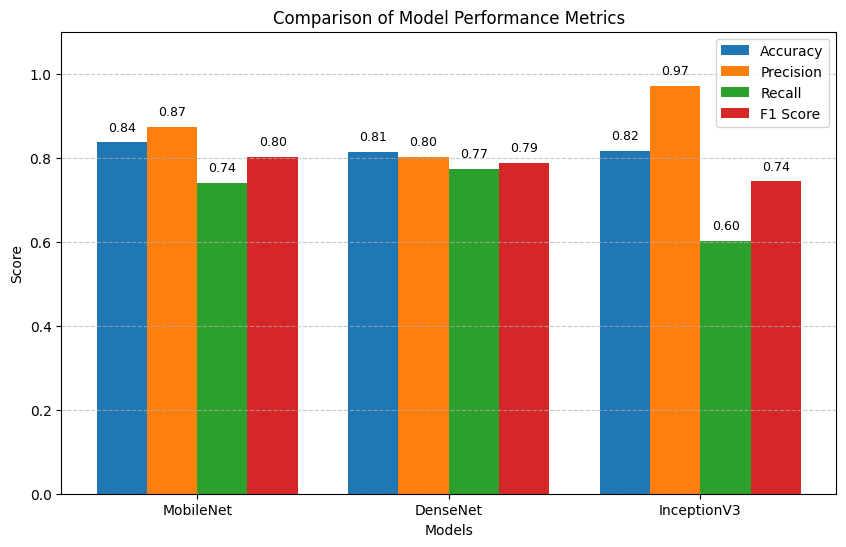

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['MobileNet', 'DenseNet', 'InceptionV3']

# Metrics
accuracy = [0.8367, 0.8144, 0.8156]
precision = [0.8732, 0.8026, 0.9718]
recall = [0.74, 0.7725, 0.6025]
f1_score = [0.8011, 0.7873, 0.7438]

# Set width of bar
bar_width = 0.2
x = np.arange(len(models))

# Create subplots
plt.figure(figsize=(10,6))
bars1 = plt.bar(x - 1.5*bar_width, accuracy, width=bar_width, label='Accuracy')
bars2 = plt.bar(x - 0.5*bar_width, precision, width=bar_width, label='Precision')
bars3 = plt.bar(x + 0.5*bar_width, recall, width=bar_width, label='Recall')
bars4 = plt.bar(x + 1.5*bar_width, f1_score, width=bar_width, label='F1 Score')

# Function to add value labels on bars
def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
                 ha='center', va='bottom', fontsize=9)

# Add values to all bars
add_values(bars1)
add_values(bars2)
add_values(bars3)
add_values(bars4)

# Labels and title
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Model Performance Metrics')
plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [44]:
import pandas as pd

data = {
    'Model': ['MobileNetV2', 'DenseNet121', 'InceptionV3'],
    'Accuracy': [0.8367, 0.8144, 0.8156],
    'Precision': [0.8732, 0.8026, 0.9718],
    'Recall': [0.74, 0.7725, 0.6025],
    'F1 Score': [0.8011, 0.7873, 0.7438]
}

# Create DataFrame
df = pd.DataFrame(data)


df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(3)

# Display the table
print(df)

         Model  Accuracy  Precision  Recall  F1 Score
0  MobileNetV2     0.837      0.873   0.740     0.801
1  DenseNet121     0.814      0.803   0.772     0.787
2  InceptionV3     0.816      0.972   0.602     0.744
